In [4]:
#!mv /kaggle/input/features/pytorch/size80/2 /kaggle/working

In [5]:
import os, json, random, subprocess
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from typing import Callable
from itertools import chain

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.parallel import DataParallel

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report, precision_recall_fscore_support

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import timm

try: 
    from torchmil.models import MILModel
    from torchmil.nn import AttentionPool
    from torchmil.datasets import ProcessedMILDataset
    from torchmil.data import collate_fn as mil_collate_fn
except: 
    !pip install -q torchmil
    from torchmil.models import MILModel
    from torchmil.nn import AttentionPool
    from torchmil.datasets import ProcessedMILDataset
    from torchmil.data import collate_fn as mil_collate_fn

try:
    from huggingface_hub import login
except:
    !pip install -q huggingface_hub
    from huggingface_hub import login

import optuna
from optuna.visualization import plot_param_importances

import warnings
warnings.filterwarnings('ignore')

# Configuration
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
MULTIPLE_GPUS = NUM_GPUS > 1
USE_MULTI_GPU_FEATURES = MULTIPLE_GPUS

KAGGLE = True
if KAGGLE:
    BASE_DIR = "/kaggle/input/grumpy-doctogres/patches_80"
    TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train", "imgs")
    TRAIN_MASK_DIR = os.path.join(BASE_DIR, "train", "masks")
    TEST_IMG_DIR = os.path.join(BASE_DIR, "test", "imgs")
    TEST_MASK_DIR = os.path.join(BASE_DIR, "test", "masks")
    TRAIN_LABELS_PATH = os.path.join(BASE_DIR, "train_labels.csv")
    FEATURES_DIR = Path("/kaggle/working/2/train_features/features")
    TEST_FEATURES_DIR = Path("/kaggle/working/2/test_features/test_features/test_features")
    STUDY_PATH = "/kaggle/working/optuna-studies"
else:
    BASE_DIR = "./data"
    TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train", "imgs")
    TRAIN_MASK_DIR = os.path.join(BASE_DIR, "train", "masks")
    TEST_IMG_DIR = os.path.join(BASE_DIR, "test", "imgs")
    TEST_MASK_DIR = os.path.join(BASE_DIR, "test", "masks")
    TRAIN_LABELS_PATH = os.path.join(BASE_DIR, "train_labels.csv")
    FEATURES_DIR = Path("./features")
    TEST_FEATURES_DIR = Path("./test_features")
    STUDY_PATH = "./optuna-studies"

MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
TEST_FEATURES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for idx, name in enumerate(CLASS_NAMES)}
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
RESNET_INPUT_SIZE = 224

MIL_BATCH_SIZE = 256
K_FOLDS = 5
F1_TYPE = 'micro'

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(SEED)

def get_base_model(model):
    return model.module if isinstance(model, DataParallel) else model

print(f"Device: {DEVICE} | GPUs: {NUM_GPUS} | Classes: {NUM_CLASSES}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 5.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.6/447.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
from kaggle_secrets import UserSecretsClient

try:
    hf_token = UserSecretsClient().get_secret("HF-Angelo")
    login(token=hf_token)
    print("Logged in to Hugging Face successfully.")
except Exception as e:
    print(f"Authentication warning: {e}")
    print("Ensure you have set the 'HUGGINGFACE_TOKEN' secret to access UNI2-h.")

Logged in to Hugging Face successfully.


In [7]:
def get_original_image_id(img_name):
    name = os.path.splitext(img_name)[0]
    ext = os.path.splitext(img_name)[1]
    return (name.split('_r')[0] + ext) if '_r' in name else img_name

def get_mask_path(img_path, mask_dir):
    name = os.path.basename(img_path)
    mask_name = 'mask_' + name[4:] if name.startswith('img_') else name
    return os.path.join(mask_dir, mask_name)

def load_train_data(img_dir, mask_dir, labels_path):
    labels_df = pd.read_csv(labels_path)
    label_lookup = {row.iloc[0]: CLASS_TO_IDX[row.iloc[1]] for _, row in labels_df.iterrows()}
    
    img_paths, mask_paths, labels, orig_indices = [], [], [], []
    for name in sorted(os.listdir(img_dir)):
        if not name.endswith(('.png', '.jpg', '.jpeg')): continue
        img_path = os.path.join(img_dir, name)
        mask_path = get_mask_path(img_path, mask_dir)
        orig_id = get_original_image_id(name)
        if orig_id not in label_lookup or not os.path.exists(mask_path): continue
        img_paths.append(img_path)
        mask_paths.append(mask_path)
        labels.append(label_lookup[orig_id])
        orig_indices.append(orig_id)
    
    return np.array(img_paths), np.array(mask_paths), np.array(labels), np.array(orig_indices), label_lookup

def load_test_data(img_dir, mask_dir):
    img_paths, mask_paths, names, orig_indices = [], [], [], []
    for name in sorted(os.listdir(img_dir)):
        if not name.endswith(('.png', '.jpg', '.jpeg')): continue
        img_path = os.path.join(img_dir, name)
        mask_path = get_mask_path(img_path, mask_dir)
        if not os.path.exists(mask_path): continue
        img_paths.append(img_path)
        mask_paths.append(mask_path)
        names.append(name)
        orig_indices.append(get_original_image_id(name))
    return np.array(img_paths), np.array(mask_paths), np.array(names), np.array(orig_indices)

def get_bag_names(orig_indices):
    return [img_id.replace('.png', '').replace('.jpg', '') for img_id in np.unique(orig_indices)]

def get_image_labels(orig_indices, label_lookup):
    unique = np.unique(orig_indices)
    return unique, np.array([label_lookup[img_id] for img_id in unique])

try:
    train_img_paths, train_mask_paths, train_labels, train_orig_indices, image_label_lookup = load_train_data(
        TRAIN_IMG_DIR, TRAIN_MASK_DIR, TRAIN_LABELS_PATH)
    unique_images, unique_labels = get_image_labels(train_orig_indices, image_label_lookup)
    print(f"Training: {len(train_img_paths)} patches, {len(unique_images)} images")
    print("Class distribution:", dict(zip(CLASS_NAMES, np.bincount(unique_labels, minlength=NUM_CLASSES))))
except Exception as e:
    print(f"Could not load training data: {e}")
    train_img_paths, train_mask_paths, train_labels, train_orig_indices = np.array([]), np.array([]), np.array([]), np.array([])
    image_label_lookup = {}

Training: 6689 patches, 581 images
Class distribution: {'HER2(+)': 150, 'Luminal A': 158, 'Luminal B': 204, 'Triple negative': 69}


In [8]:
class DeterministicAugTransform:
    AUGMENTATIONS = {
        'original': {},
        'augmix': {'augmix': True, 'severity': 3, 'mixture_width': 3, 'alpha': 1.0},
        'hflip': {'hflip': True}, 'vflip': {'vflip': True}, 'hvflip': {'hflip': True, 'vflip': True},
        'rot90': {'rotation': 90}, 'rot180': {'rotation': 180}, 'rot270': {'rotation': 270},
    }

    '''  
        'hflip_rot90': {'hflip': True, 'rotation': 90}, 'hflip_rot180': {'hflip': True, 'rotation': 180},
        'hflip_rot270': {'hflip': True, 'rotation': 270}, 'vflip_rot90': {'vflip': True, 'rotation': 90},
        'vflip_rot180': {'vflip': True, 'rotation': 180}, 'vflip_rot270': {'vflip': True, 'rotation': 270},
    '''
    
    @classmethod
    def get_all_names(cls): return list(cls.AUGMENTATIONS.keys())
    
    def __init__(self, aug_type='original', size=RESNET_INPUT_SIZE):
        self.aug_type = aug_type
        self.config = self.AUGMENTATIONS.get(aug_type, {})
        self.size = size
    
    def __call__(self, img_path):
        img = Image.open(img_path).convert('RGB')
        if self.config.get('hflip'): img = transforms.functional.hflip(img)
        if self.config.get('vflip'): img = transforms.functional.vflip(img)
        if rot := self.config.get('rotation'): img = transforms.functional.rotate(img, rot)
        if self.config.get('augmix'):
            img = transforms.AugMix(
                severity=self.config.get('severity', 3),
                mixture_width=self.config.get('mixture_width', 3),
                alpha=self.config.get('alpha', 1.0)
            )(img)
        tensor = transforms.functional.to_tensor(img)
        tensor = transforms.functional.normalize(tensor, IMAGENET_MEAN, IMAGENET_STD)
        return transforms.functional.resize(tensor, (self.size, self.size))
    
    def transform_mask(self, mask_path, size=None):
        """Transform mask with same geometric augmentations (no color augmentations like augmix)."""
        size = size or self.size
        mask = Image.open(mask_path).convert('L')  # Load as grayscale
        if self.config.get('hflip'): mask = transforms.functional.hflip(mask)
        if self.config.get('vflip'): mask = transforms.functional.vflip(mask)
        if rot := self.config.get('rotation'): mask = transforms.functional.rotate(mask, rot)
        # No augmix for masks - it's only for RGB images
        tensor = transforms.functional.to_tensor(mask)  # Shape: (1, H, W), values in [0, 1]
        return transforms.functional.resize(tensor, (size, size))


def filter_augmentations(available, aug_params=None):
    aug_params = aug_params or {}
    selected = ['original']
    if aug_params.get('use_hflip') and 'hflip' in available: selected.append('hflip')
    if aug_params.get('use_vflip') and 'vflip' in available: selected.append('vflip')
    if aug_params.get('use_hflip') and aug_params.get('use_vflip') and 'hvflip' in available: selected.append('hvflip')
    if aug_params.get('use_rotation'):
        for r in ['rot90', 'rot180', 'rot270']:
            if r in available: selected.append(r)
    if aug_params.get('use_flip_rotation_combos'):
        for c in ['hflip_rot90', 'hflip_rot180', 'hflip_rot270', 'vflip_rot90', 'vflip_rot180', 'vflip_rot270']:
            if c in available: selected.append(c)
    if aug_params.get('use_augmix') and 'augmix' in available: selected.append('augmix')
    return list(dict.fromkeys(selected))


class MILDatasetWithMasks(Dataset):
    """MIL Dataset that loads pre-extracted RGB features and pre-extracted mask features.
    
    RGB features are pre-extracted from UNI2-h (frozen backbone).
    Mask features are pre-extracted from ConvNeXt-T (frozen backbone).
    Both are loaded from disk for fast training.
    """
    def __init__(self, features_dir, labels_dir, bag_names, mask_features_dir=None):
        self.features_dir = Path(features_dir)
        self.labels_dir = Path(labels_dir)
        self.bag_names = bag_names
        self.mask_features_dir = Path(mask_features_dir) if mask_features_dir else None
        self.use_masks = self.mask_features_dir is not None and self.mask_features_dir.exists()
    
    def __len__(self):
        return len(self.bag_names)
    
    def __getitem__(self, idx):
        bag_name = self.bag_names[idx]
        
        # Load pre-extracted RGB features
        feat_file = self.features_dir / f'{bag_name}.npy'
        features = torch.from_numpy(np.load(feat_file)).float()
        num_patches = features.shape[0]
        
        # Load label
        label_file = self.labels_dir / f'{bag_name}.npy'
        label = torch.from_numpy(np.load(label_file)).long().squeeze()
        
        # Load pre-extracted mask features
        mask_features = None
        if self.use_masks:
            mask_feat_file = self.mask_features_dir / f'{bag_name}.npy'
            if mask_feat_file.exists():
                mask_features = torch.from_numpy(np.load(mask_feat_file)).float()
                # Ensure mask features match number of RGB patches
                if mask_features.shape[0] != num_patches:
                    # Pad or truncate as needed
                    if mask_features.shape[0] < num_patches:
                        pad = torch.zeros(num_patches - mask_features.shape[0], mask_features.shape[1])
                        mask_features = torch.cat([mask_features, pad], dim=0)
                    else:
                        mask_features = mask_features[:num_patches]
        
        return {
            'X': features,
            'Y': label,
            'mask_features': mask_features,  # Pre-extracted mask features (N, mask_feature_dim) or None
            'bag_name': bag_name,
            'num_patches': num_patches
        }


def mil_collate_with_masks(batch):
    """Custom collate function that handles pre-extracted RGB and mask features."""
    max_len = max(item['X'].shape[0] for item in batch)
    
    X_list, Y_list, attn_mask_list, mask_feats_list, names = [], [], [], [], []
    has_mask_features = batch[0]['mask_features'] is not None
    
    for item in batch:
        X = item['X']
        seq_len = X.shape[0]
        
        # Pad RGB features
        if seq_len < max_len:
            pad = torch.zeros(max_len - seq_len, X.shape[1])
            X = torch.cat([X, pad], dim=0)
        X_list.append(X)
        
        # Create attention mask
        attn_mask = torch.zeros(max_len, dtype=torch.bool)
        attn_mask[:seq_len] = True
        attn_mask_list.append(attn_mask)
        
        # Pad mask features if available
        if has_mask_features and item['mask_features'] is not None:
            mf = item['mask_features']  # (N, mask_feature_dim)
            if mf.shape[0] < max_len:
                pad = torch.zeros(max_len - mf.shape[0], mf.shape[1])
                mf = torch.cat([mf, pad], dim=0)
            mask_feats_list.append(mf)
        
        Y_list.append(item['Y'])
        names.append(item['bag_name'])
    
    result = {
        'X': torch.stack(X_list),
        'Y': torch.stack(Y_list),
        'mask': torch.stack(attn_mask_list),
        'bag_name': names
    }
    
    if has_mask_features and mask_feats_list:
        result['mask_features'] = torch.stack(mask_feats_list)  # (B, N, mask_feature_dim)
    
    return result


def build_mask_paths_lookup(mask_paths, original_indices):
    """Build a lookup from original image ID to list of mask paths."""
    lookup = {}
    for mask_path, orig_id in zip(mask_paths, original_indices):
        orig_id_clean = orig_id.replace('.png', '').replace('.jpg', '')
        if orig_id_clean not in lookup:
            lookup[orig_id_clean] = []
        lookup[orig_id_clean].append(mask_path)
    return lookup


def create_mil_dataloaders(features_dir, labels_dir, train_names, val_names, augmentations=None, 
                           batch_size=MIL_BATCH_SIZE, mask_features_dir=None):
    """Create train/val MIL dataloaders with pre-extracted mask features support."""
    # For training: include augmented versions
    train_bag_names = []
    for name in train_names:
        for aug in (augmentations or ['original']):
            train_bag_names.append(f"{name}_{aug}")
    
    # For validation: only original
    val_bag_names = [f"{name}_original" for name in val_names]
    
    train_ds = MILDatasetWithMasks(features_dir, labels_dir, train_bag_names, mask_features_dir)
    val_ds = MILDatasetWithMasks(features_dir, labels_dir, val_bag_names, mask_features_dir)
    
    return (DataLoader(train_ds, batch_size, shuffle=True, collate_fn=mil_collate_with_masks, pin_memory=True, num_workers=0),
            DataLoader(val_ds, batch_size, shuffle=False, collate_fn=mil_collate_with_masks, pin_memory=True, num_workers=0))

print("Transforms and datasets ready (with pre-extracted mask features from ConvNeXt-T).")

Transforms and datasets ready (with pre-extracted mask features from ConvNeXt-T).


In [9]:
class GradCAMPlusPlus:
    def __init__(self, model, target_layer=None):
        self.model = model
        self.gradients = self.activations = None
        self.handles = []
        base_model = get_base_model(model)
        self.target_layer = target_layer or base_model.rgb_features[-1]
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(m, i, o): self.activations = o.detach()
        def backward_hook(m, gi, go): self.gradients = go[0].detach()
        self.handles = [self.target_layer.register_forward_hook(forward_hook),
                       self.target_layer.register_full_backward_hook(backward_hook)]
    
    def remove_hooks(self):
        for h in self.handles: h.remove()
    
    def __call__(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        logits = output[0] if isinstance(output, tuple) else output
        probs = F.softmax(logits, dim=1)
        target_class = target_class if target_class is not None else logits.argmax(dim=1).item()
        
        self.model.zero_grad()
        one_hot = torch.zeros_like(logits); one_hot[0, target_class] = 1
        logits.backward(gradient=one_hot, retain_graph=True)
        
        grad_2, grad_3 = self.gradients ** 2, self.gradients ** 3
        alpha = grad_2 / (2 * grad_2 + (self.activations * grad_3).sum((2,3), keepdim=True) + 1e-8)
        weights = (alpha * F.relu(self.gradients)).sum((2,3), keepdim=True)
        heatmap = F.relu((weights * self.activations).sum(1, keepdim=True)).squeeze().cpu().numpy()
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        return heatmap, target_class, probs[0].detach().cpu().numpy()


class CAMResNet(nn.Module):
    """Two-Tower UNI2-h with Gated Fusion: Tower A (RGB) + Tower B (Mask) → CAM Head.
    
    Note: This model is for direct image classification, not MIL.
    Tower B uses ConvNeXt-T for mask feature extraction.
    """
    def __init__(self, num_classes=NUM_CLASSES, model_params=None, freeze_backbone=True):
        super().__init__()
        model_params = model_params or {}
        self.num_classes, self.freeze_backbone = num_classes, freeze_backbone
        
        feature_dim = model_params.get('feature_dim', 256)
        hidden_channels = model_params.get('hidden_channels', 256)
        dropout_rate = model_params.get('dropout_rate', 0.3)
        
        # Load UNI2-h backbone for RGB
        print("Loading UNI2-h backbone...")
        timm_kwargs = {
            'img_size': 224, 
            'patch_size': 14, 
            'depth': 24,
            'num_heads': 24,
            'init_values': 1e-5, 
            'embed_dim': 1536,
            'mlp_ratio': 2.66667*2,
            'num_classes': 0, 
            'no_embed_class': True,
            'mlp_layer': timm.layers.SwiGLUPacked, 
            'act_layer': torch.nn.SiLU, 
            'reg_tokens': 8, 
            'dynamic_img_size': True
        }
        uni2h_model = timm.create_model("hf-hub:MahmoodLab/UNI2-h", pretrained=True, **timm_kwargs)
        self.rgb_features = uni2h_model
        self.uni2h_feature_dim = uni2h_model.num_features  # 1536
        
        if freeze_backbone:
            for p in self.rgb_features.parameters(): p.requires_grad = False
        
        # RGB projection (from 1536 to feature_dim)
        self.rgb_proj = nn.Sequential(nn.Linear(self.uni2h_feature_dim, feature_dim), nn.ReLU(True), 
                                       nn.Dropout(dropout_rate) if dropout_rate > 0 else nn.Identity())
        
        # Load ConvNeXt-T backbone for masks (in_chans=1 for grayscale)
        print("Loading ConvNeXt-T backbone for masks...")
        mask_backbone = timm.create_model('convnext_tiny.fb_in22k_ft_in1k', pretrained=True, 
                                          in_chans=1, num_classes=0)
        self.mask_features = mask_backbone
        self.convnext_feature_dim = mask_backbone.num_features  # 768
        
        if freeze_backbone:
            for p in self.mask_features.parameters(): p.requires_grad = False
        
        # Mask projection (from 768 to feature_dim)
        self.mask_proj = nn.Sequential(nn.Linear(self.convnext_feature_dim, feature_dim), nn.ReLU(True),
                                        nn.Dropout(dropout_rate) if dropout_rate > 0 else nn.Identity())
        
        # Fusion gate
        self.fusion_gate = nn.Sequential(nn.Linear(feature_dim * 2, feature_dim), nn.Sigmoid())
        
        # CAM head
        self.cam_head = nn.Sequential(
            nn.Conv2d(feature_dim, hidden_channels, 3, 1, 1), nn.BatchNorm2d(hidden_channels), nn.ReLU(True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(hidden_channels, hidden_channels // 2, 3, 1, 1), nn.BatchNorm2d(hidden_channels // 2), nn.ReLU(True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(hidden_channels // 2, num_classes, 1))
        self.fusion_to_spatial = nn.Sequential(nn.Linear(feature_dim, feature_dim * 7 * 7), nn.Sigmoid())
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)
        self.fused_classifier = nn.Linear(feature_dim, num_classes)
    
    def forward(self, x, return_heatmaps=False):
        rgb, mask = x[:, :3], x[:, 3:4]
        
        # UNI2-h processes RGB and outputs global features
        rgb_global = self.rgb_features(rgb)  # (B, 1536)
        f_img = self.rgb_proj(rgb_global)  # (B, feature_dim)
        
        # ConvNeXt-T processes masks and outputs global features
        mask_global = self.mask_features(mask)  # (B, 768)
        f_mask = self.mask_proj(mask_global)  # (B, feature_dim)
        
        # Fusion
        gate = self.fusion_gate(torch.cat([f_img, f_mask], 1))
        fused = gate * f_img + (1 - gate) * f_mask
        
        # Create spatial representation for CAM
        spatial_fused = self.fusion_to_spatial(fused).view(-1, fused.size(1), 7, 7)
        heatmaps = self.cam_head(spatial_fused)
        
        # Final logits
        logits = 0.5 * self.global_max_pool(heatmaps).view(x.size(0), -1) + 0.5 * self.fused_classifier(fused)
        return (logits, heatmaps) if return_heatmaps else logits
    
    def unfreeze_backbone(self, num_layers=-1):
        children = list(self.rgb_features.children())
        for child in (children if num_layers == -1 else children[-num_layers:]):
            for p in child.parameters(): p.requires_grad = True
        self.freeze_backbone = False
    
    def get_trainable_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)
    def get_gradcam_plusplus(self, layer=None): return GradCAMPlusPlus(self, layer)


def create_model(model_params=None, freeze_backbone=True, use_multi_gpu=False):
    model = CAMResNet(NUM_CLASSES, model_params, freeze_backbone).to(DEVICE)
    if use_multi_gpu and MULTIPLE_GPUS: model = DataParallel(model)
    return model

print("Two-Tower UNI2-h (RGB) + ConvNeXt-T (Mask) + GradCAM++ ready.")

Two-Tower UNI2-h (RGB) + ConvNeXt-T (Mask) + GradCAM++ ready.


In [10]:
class MultiClassABMIL(MILModel):
    """Attention-Based MIL with Two-Tower fusion using torchmil's AttentionPool.
    
    Tower A: Pre-extracted RGB features from UNI2-h (frozen)
    Tower B: Pre-extracted mask features from ConvNeXt-T (frozen)
    Fusion: Gated fusion of both towers before attention pooling
    """
    def __init__(self, in_dim, num_classes, att_dim=128, hidden_dim=256, att_act='tanh', 
                 gated=True, dropout=0.3, use_mask_tower=True, mask_feature_dim=768):
        super().__init__()
        self.use_mask_tower = use_mask_tower
        self.mask_feature_dim = mask_feature_dim
        
        # Tower A: RGB feature transform (pre-extracted features from UNI2-h)
        self.rgb_transform = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Tower B: Mask feature transform (pre-extracted features from ConvNeXt-T)
        if self.use_mask_tower:
            self.mask_transform = nn.Sequential(
                nn.Linear(mask_feature_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            # Gated fusion: learns to combine RGB and mask features
            self.fusion_gate = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.Sigmoid()
            )
        
        self.pool = AttentionPool(in_dim=hidden_dim, att_dim=att_dim, act=att_act, gated=gated)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, X, mask=None, mask_features=None, return_attention=False):
        """
        X: (B, N, D) - Pre-extracted RGB features from UNI2-h
        mask: (B, N) - Attention mask (which patches are valid)
        mask_features: (B, N, mask_feature_dim) - Pre-extracted mask features from ConvNeXt-T (optional)
        """
        # Tower A: transform pre-extracted RGB features
        X_rgb = self.rgb_transform(X)
        
        # Tower B: transform pre-extracted mask features and fuse with RGB features
        if self.use_mask_tower and mask_features is not None:
            X_mask = self.mask_transform(mask_features)  # (B, N, hidden_dim)
            # Gated fusion: gate * rgb + (1 - gate) * mask
            concat = torch.cat([X_rgb, X_mask], dim=-1)
            gate = self.fusion_gate(concat)
            X_fused = gate * X_rgb + (1 - gate) * X_mask
        else:
            X_fused = X_rgb
        
        # Attention pooling
        Z = self.pool(X_fused, mask)
        Z = self.dropout(Z)
        logits = self.classifier(Z)
        
        if return_attention:
            with torch.no_grad():
                if self.pool.gated:
                    A_V = self.pool.attention_V(X_fused)
                    A_U = self.pool.attention_U(X_fused)
                    A = self.pool.attention_w(A_V * A_U).squeeze(-1)
                else:
                    A = self.pool.fc2(torch.tanh(self.pool.fc1(X_fused))).squeeze(-1)
                if mask is not None:
                    A = A.masked_fill(~mask, -1e9)
                attn = F.softmax(A, dim=1)
            return logits, attn
        return logits
    
    def get_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def create_mil_model(feature_dim, mil_params=None, use_multi_gpu=False, use_mask_tower=None, mask_feature_dim=768):
    """Create MIL model with optional Two-Tower architecture.
    
    Args:
        feature_dim: Input feature dimension from UNI2-h (e.g., 1536)
        mil_params: Dict with MIL hyperparameters
        use_multi_gpu: Whether to wrap with DataParallel
        use_mask_tower: Override for whether to use Tower B. If None, uses mil_params['use_mask_tower']
        mask_feature_dim: Feature dimension from ConvNeXt-T (default 768)
    """
    mil_params = mil_params or {}
    # Allow explicit override of use_mask_tower
    _use_mask_tower = use_mask_tower if use_mask_tower is not None else mil_params.get('use_mask_tower', True)
    _mask_feature_dim = mil_params.get('mask_feature_dim', mask_feature_dim)
    
    model = MultiClassABMIL(
        in_dim=feature_dim,
        att_dim=mil_params.get('att_dim', 128),
        hidden_dim=mil_params.get('hidden_dim', 256),
        gated=mil_params.get('gated', True),
        dropout=mil_params.get('dropout', 0.3),
        num_classes=NUM_CLASSES,
        use_mask_tower=_use_mask_tower,
        mask_feature_dim=_mask_feature_dim
    ).to(DEVICE)
    
    if use_multi_gpu and MULTIPLE_GPUS:
        model = DataParallel(model)
    
    return model

print("MIL model ready with Two-Tower fusion (Tower B uses pre-extracted ConvNeXt-T mask features).")

MIL model ready with Two-Tower fusion (Tower B uses pre-extracted ConvNeXt-T mask features).


In [11]:
class FeatureExtractor(nn.Module):
    """UNI2-h feature extractor for Tower A (RGB features only)."""
    def __init__(self, device=DEVICE, use_multi_gpu=False):
        super().__init__()
        print("Initializing UNI2-h feature extractor...")
        timm_kwargs = {
            'img_size': 224, 
            'patch_size': 14, 
            'depth': 24,
            'num_heads': 24,
            'init_values': 1e-5, 
            'embed_dim': 1536,
            'mlp_ratio': 2.66667*2,
            'num_classes': 0, 
            'no_embed_class': True,
            'mlp_layer': timm.layers.SwiGLUPacked, 
            'act_layer': torch.nn.SiLU, 
            'reg_tokens': 8, 
            'dynamic_img_size': True
        }
        backbone = timm.create_model("hf-hub:MahmoodLab/UNI2-h", pretrained=True, **timm_kwargs)
        self.feature_dim = backbone.num_features  # 1536 for UNI2-h

        for p in backbone.parameters():
            p.requires_grad = False

        self.device = device
        self.use_multi_gpu = use_multi_gpu and MULTIPLE_GPUS
        if self.use_multi_gpu:
            self.features = DataParallel(backbone).to(device)
            print(f"UNI2-h loaded across {NUM_GPUS} GPUs for feature extraction")
        else:
            self.features = backbone.to(device)
            print("UNI2-h loaded on single device for feature extraction")
        self.features.eval()
        print(f"UNI2-h ready. Feature dimension: {self.feature_dim}")
    
    def forward(self, rgb): 
        with torch.no_grad(): 
            features = self.features(rgb)
            return features
    
    def extract_features(self, rgb):
        return self.forward(rgb)


class MaskFeatureExtractor(nn.Module):
    """ConvNeXt-T feature extractor for Tower B (Mask features only).
    Uses in_chans=1 since masks are grayscale/binary images.
    """
    def __init__(self, device=DEVICE, use_multi_gpu=False):
        super().__init__()
        print("Initializing ConvNeXt-T feature extractor for masks...")
        # Load ConvNeXt-T with 1 input channel for grayscale masks
        backbone = timm.create_model(
            'convnext_tiny.fb_in22k_ft_in1k',
            pretrained=True,
            in_chans=1,  # Single channel for grayscale masks
            num_classes=0  # Remove classification head, get features only
        )
        self.feature_dim = backbone.num_features  # 768 for ConvNeXt-T

        for p in backbone.parameters():
            p.requires_grad = False

        self.device = device
        self.use_multi_gpu = use_multi_gpu and MULTIPLE_GPUS
        if self.use_multi_gpu:
            self.features = DataParallel(backbone).to(device)
            print(f"ConvNeXt-T loaded across {NUM_GPUS} GPUs for mask feature extraction")
        else:
            self.features = backbone.to(device)
            print("ConvNeXt-T loaded on single device for mask feature extraction")
        self.features.eval()
        print(f"ConvNeXt-T ready. Mask feature dimension: {self.feature_dim}")
    
    def forward(self, mask): 
        with torch.no_grad(): 
            features = self.features(mask)
            return features
    
    def extract_features(self, mask):
        return self.forward(mask)


def extract_and_cache_features(image_paths, original_indices, label_lookup, extractor, output_dir, augmentations, batch_size=64, device=DEVICE):
    """Extract and cache RGB features from UNI2-h backbone."""
    output_dir = Path(output_dir)
    (features_dir := output_dir / 'features').mkdir(parents=True, exist_ok=True)
    (labels_dir := output_dir / 'labels').mkdir(parents=True, exist_ok=True)
    device = getattr(extractor, 'device', device)
    
    unique_images = np.unique(original_indices)
    aug_names = [a[0] for a in augmentations]
    print(f"Extracting RGB features for {len(unique_images)} images, {len(augmentations)} augmentations...")
    print(f"  UNI2-h backbone: {extractor.feature_dim}-dim vectors")
    print(f"  Output directory: {output_dir}")
    
    for img_id in tqdm(unique_images, desc="Extracting RGB features"):
        bag_name = img_id.replace('.png', '').replace('.jpg', '')
        
        # Save label (same for all augmentations of this bag)
        label_file = labels_dir / f'{bag_name}.npy'
        if not label_file.exists(): 
            np.save(label_file, np.array([label_lookup.get(img_id, 0)]))
        
        img_paths_for_bag = image_paths[original_indices == img_id]
        
        for aug_name, transform in augmentations:
            feat_file = features_dir / f'{bag_name}_{aug_name}.npy'
            if feat_file.exists(): continue
            
            # Extract RGB features
            all_feats = []
            for i in range(0, len(img_paths_for_bag), batch_size):
                batch = torch.stack([transform(p) for p in img_paths_for_bag[i:i+batch_size]]).to(device)
                with torch.no_grad(): 
                    feats = extractor.extract_features(batch)
                    all_feats.append(feats.cpu().numpy())
            stacked_feats = np.concatenate(all_feats, 0)
            np.save(feat_file, stacked_feats)
            
            # Also save label with augmentation name for dataset
            aug_label_file = labels_dir / f'{bag_name}_{aug_name}.npy'
            if not aug_label_file.exists():
                np.save(aug_label_file, np.array([label_lookup.get(img_id, 0)]))
    
    config = {
        'feature_dim': extractor.feature_dim,
        'backbone': 'uni2-h',
        'augmentations': aug_names,
        'feature_shape': f'[N, {extractor.feature_dim}]'
    }
    with open(output_dir / 'config.json', 'w') as f:
        json.dump(config, f, indent=2)
    print(f"✅ RGB features saved to {output_dir}")
    return output_dir


def extract_and_cache_mask_features(mask_paths, original_indices, extractor, output_dir, augmentations, batch_size=64, device=DEVICE):
    """Extract and cache mask features from ConvNeXt-T backbone.
    
    Args:
        mask_paths: Array of mask file paths
        original_indices: Array of original image IDs (same length as mask_paths)
        extractor: MaskFeatureExtractor instance
        output_dir: Directory to save features
        augmentations: List of (aug_name, transform) tuples
        batch_size: Batch size for extraction
        device: Device to use
    """
    output_dir = Path(output_dir)
    (features_dir := output_dir / 'mask_features').mkdir(parents=True, exist_ok=True)
    device = getattr(extractor, 'device', device)
    
    unique_images = np.unique(original_indices)
    aug_names = [a[0] for a in augmentations]
    print(f"Extracting mask features for {len(unique_images)} images, {len(augmentations)} augmentations...")
    print(f"  ConvNeXt-T backbone: {extractor.feature_dim}-dim vectors")
    print(f"  Output directory: {output_dir / 'mask_features'}")
    
    for img_id in tqdm(unique_images, desc="Extracting mask features"):
        bag_name = img_id.replace('.png', '').replace('.jpg', '')
        mask_paths_for_bag = mask_paths[original_indices == img_id]
        
        for aug_name, transform in augmentations:
            feat_file = features_dir / f'{bag_name}_{aug_name}.npy'
            if feat_file.exists(): continue
            
            # Extract mask features
            all_feats = []
            for i in range(0, len(mask_paths_for_bag), batch_size):
                batch_masks = []
                for mp in mask_paths_for_bag[i:i+batch_size]:
                    mask_tensor = transform.transform_mask(mp)  # (1, H, W)
                    batch_masks.append(mask_tensor)
                batch = torch.stack(batch_masks).to(device)  # (B, 1, H, W)
                with torch.no_grad(): 
                    feats = extractor.extract_features(batch)
                    all_feats.append(feats.cpu().numpy())
            stacked_feats = np.concatenate(all_feats, 0)
            np.save(feat_file, stacked_feats)
    
    config = {
        'feature_dim': extractor.feature_dim,
        'backbone': 'convnext_tiny',
        'augmentations': aug_names,
        'feature_shape': f'[N, {extractor.feature_dim}]'
    }
    with open(output_dir / 'mask_config.json', 'w') as f:
        json.dump(config, f, indent=2)
    print(f"✅ Mask features saved to {output_dir / 'mask_features'}")
    return output_dir / 'mask_features'


def extract_test_features(image_paths, original_indices, extractor, output_dir, augmentations=None, batch_size=64, device=DEVICE):
    """Extract test RGB features from UNI2-h backbone."""
    output_dir = Path(output_dir)
    (features_dir := output_dir / 'features').mkdir(parents=True, exist_ok=True)
    device = getattr(extractor, 'device', device)
    
    augmentations = augmentations or [('original', DeterministicAugTransform('original'))]
    unique_images = np.unique(original_indices)
    aug_names = [a[0] for a in augmentations]
    
    print(f"Extracting test RGB features for {len(unique_images)} images, {len(augmentations)} augmentations...")
    print(f"  UNI2-h backbone: {extractor.feature_dim}-dim vectors")
    
    for img_id in tqdm(unique_images, desc="Test RGB extraction"):
        bag_name = img_id.replace('.png', '').replace('.jpg', '')
        img_paths_for_bag = image_paths[original_indices == img_id]
        
        for aug_name, transform in augmentations:
            feat_file = features_dir / f'{bag_name}_{aug_name}.npy'
            if feat_file.exists(): continue
            
            all_feats = []
            for i in range(0, len(img_paths_for_bag), batch_size):
                batch = torch.stack([transform(p) for p in img_paths_for_bag[i:i+batch_size]]).to(device)
                with torch.no_grad():
                    feats = extractor.extract_features(batch)
                    all_feats.append(feats.cpu().numpy())
            stacked_feats = np.concatenate(all_feats, 0)
            np.save(feat_file, stacked_feats)
    
    config = {
        'feature_dim': extractor.feature_dim,
        'backbone': 'uni2-h',
        'augmentations': aug_names,
        'feature_shape': f'[N, {extractor.feature_dim}]'
    }
    with open(output_dir / 'config.json', 'w') as f:
        json.dump(config, f, indent=2)
    print(f"✅ Test RGB features saved to {output_dir}")


def extract_test_mask_features(mask_paths, original_indices, extractor, output_dir, augmentations=None, batch_size=64, device=DEVICE):
    """Extract test mask features from ConvNeXt-T backbone."""
    output_dir = Path(output_dir)
    (features_dir := output_dir / 'mask_features').mkdir(parents=True, exist_ok=True)
    device = getattr(extractor, 'device', device)
    
    augmentations = augmentations or [('original', DeterministicAugTransform('original'))]
    unique_images = np.unique(original_indices)
    aug_names = [a[0] for a in augmentations]
    
    print(f"Extracting test mask features for {len(unique_images)} images, {len(augmentations)} augmentations...")
    print(f"  ConvNeXt-T backbone: {extractor.feature_dim}-dim vectors")
    
    for img_id in tqdm(unique_images, desc="Test mask extraction"):
        bag_name = img_id.replace('.png', '').replace('.jpg', '')
        mask_paths_for_bag = mask_paths[original_indices == img_id]
        
        for aug_name, transform in augmentations:
            feat_file = features_dir / f'{bag_name}_{aug_name}.npy'
            if feat_file.exists(): continue
            
            all_feats = []
            for i in range(0, len(mask_paths_for_bag), batch_size):
                batch_masks = []
                for mp in mask_paths_for_bag[i:i+batch_size]:
                    mask_tensor = transform.transform_mask(mp)  # (1, H, W)
                    batch_masks.append(mask_tensor)
                batch = torch.stack(batch_masks).to(device)  # (B, 1, H, W)
                with torch.no_grad():
                    feats = extractor.extract_features(batch)
                    all_feats.append(feats.cpu().numpy())
            stacked_feats = np.concatenate(all_feats, 0)
            np.save(feat_file, stacked_feats)
    
    config = {
        'feature_dim': extractor.feature_dim,
        'backbone': 'convnext_tiny',
        'augmentations': aug_names,
        'feature_shape': f'[N, {extractor.feature_dim}]'
    }
    with open(output_dir / 'mask_config.json', 'w') as f:
        json.dump(config, f, indent=2)
    print(f"✅ Test mask features saved to {output_dir / 'mask_features'}")

In [12]:
def doubling_frequency256(state):
    if "last_update" not in state:
        state["last_update"], state['precondition_frequency'] = 0, state.get('precondition_frequency', 10)
        return True
    if state['step'] - state['last_update'] >= state['precondition_frequency']:
        state['last_update'] = state['step']
        state['precondition_frequency'] = min(256, state['precondition_frequency'] * 2)
        return True
    return False

class SOAP(optim.Optimizer):
    def __init__(self, params, lr=3e-3, betas=(0.95, 0.95), shampoo_beta=-1, eps=1e-8, weight_decay=0.01,
                 precondition_frequency=10, precondition_frequency_routine=doubling_frequency256,
                 max_precond_dim=10000, merge_dims=False, precondition_1d=False, normalize_grads=False, correct_bias=True):
        defaults = dict(lr=lr, betas=betas, shampoo_beta=shampoo_beta, eps=eps, weight_decay=weight_decay,
                       precondition_frequency=precondition_frequency, precondition_frequency_routine=precondition_frequency_routine,
                       max_precond_dim=max_precond_dim, merge_dims=merge_dims, precondition_1d=precondition_1d,
                       normalize_grads=normalize_grads, correct_bias=correct_bias)
        super().__init__(params, defaults)

    def merge_dims(self, grad, max_precond_dim):
        shape, new_shape, curr = grad.shape, [], 1
        for sh in shape:
            if (temp := curr * sh) > max_precond_dim:
                if curr > 1: new_shape.append(curr); curr = sh
                else: new_shape.append(sh); curr = 1
            else: curr = temp
        if curr > 1 or not new_shape: new_shape.append(curr)
        return grad.reshape(new_shape)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure else None
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                grad, state = p.grad, self.state[p]
                if "step" not in state: state["step"] = 0
                if "exp_avg" not in state:
                    state["exp_avg"] = torch.zeros_like(grad)
                    state["exp_avg_sq"] = torch.zeros_like(grad)
                if 'Q' not in state:
                    self._init_precond(grad, state, group); self._update_precond(grad, state, group); continue
                
                grad_proj = self._project(grad, state, group)
                beta1, beta2 = group["betas"]
                state["step"] += 1
                state["exp_avg"].mul_(beta1).add_(grad_proj, alpha=1-beta1)
                state["exp_avg_sq"].mul_(beta2).add_(grad_proj.square(), alpha=1-beta2)
                
                step_size = group["lr"]
                if group["correct_bias"]:
                    step_size *= (1 - beta2**state["step"])**0.5 / (1 - beta1**state["step"])
                
                norm_grad = self._project_back(state["exp_avg"] / (state["exp_avg_sq"].sqrt() + group["eps"]), state, group)
                if group["normalize_grads"]: norm_grad /= (1e-30 + (norm_grad**2).mean()**0.5)
                p.add_(norm_grad, alpha=-step_size)
                if group["weight_decay"] > 0: p.add_(p, alpha=-group["lr"] * group["weight_decay"])
                self._update_precond(grad, state, group)
        return loss

    def _init_precond(self, grad, state, group):
        state['GG'] = [torch.zeros(sh, sh, device=grad.device) if sh <= group['max_precond_dim'] else [] 
                       for sh in (self.merge_dims(grad, group['max_precond_dim']).shape if group['merge_dims'] else grad.shape)] if grad.dim() > 1 else \
                      ([torch.zeros(grad.shape[0], grad.shape[0], device=grad.device)] if group['precondition_1d'] and grad.shape[0] <= group['max_precond_dim'] else [[]])
        state['Q'], state['precondition_frequency'] = None, group['precondition_frequency']
        state['precondition_frequency_routine'], state['shampoo_beta'] = group['precondition_frequency_routine'], group['shampoo_beta'] if group['shampoo_beta'] >= 0 else group["betas"][1]

    def _project(self, grad, state, group):
        if group['merge_dims']: grad = self.merge_dims(grad, group['max_precond_dim'])
        for mat in state['Q']:
            grad = torch.tensordot(grad, mat, dims=[[0], [0]]) if len(mat) else grad.permute(list(range(1, grad.dim())) + [0])
        return grad

    def _project_back(self, grad, state, group):
        for mat in state['Q']:
            grad = torch.tensordot(grad, mat, dims=[[0], [1]]) if len(mat) else grad.permute(list(range(1, grad.dim())) + [0])
        return grad

    def _update_precond(self, grad, state, group):
        if state["Q"] is not None: state["exp_avg"] = self._project_back(state["exp_avg"], state, group)
        g = self.merge_dims(grad, group['max_precond_dim']) if group['merge_dims'] else grad
        for idx, (gg, sh) in enumerate(zip(state['GG'], g.shape)):
            if len(gg): gg.lerp_(torch.tensordot(g, g, dims=[[*range(idx), *range(idx+1, g.dim())]]*2), 1-state['shampoo_beta'])
        if state['Q'] is None:
            state['Q'] = [torch.flip(torch.linalg.eigh(m + 1e-30*torch.eye(m.shape[0], device=m.device))[1], [1]) if len(m) else [] for m in state['GG']]
        elif state['step'] > 0 and state['precondition_frequency_routine'](state):
            state['Q'] = [torch.linalg.qr(m @ o)[0] if len(m) else [] for m, o in zip(state['GG'], state['Q'])]
        if state["step"] > 0: state["exp_avg"] = self._project(state["exp_avg"], state, group)


def train_one_epoch_mil(model, loader, criterion, optimizer, scaler, device):
    """Train one epoch with pre-extracted RGB and mask features."""
    model.train()
    total_loss, preds, labels, n = 0., [], [], 0
    for batch in loader:
        feats = batch['X'].to(device)
        lbls = batch['Y'].squeeze().long().to(device)
        attn_mask = batch['mask'].to(device) if 'mask' in batch else None
        
        # Get pre-extracted mask features
        mask_features = batch.get('mask_features', None)
        if mask_features is not None:
            mask_features = mask_features.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
            logits = model(feats, attn_mask, mask_features=mask_features)
            loss = criterion(logits, lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * lbls.size(0); n += lbls.size(0)
        preds.extend(logits.argmax(1).cpu().numpy()); labels.extend(lbls.cpu().numpy())
    return total_loss / max(n, 1), f1_score(labels, preds, average=F1_TYPE) if labels else 0.


def validate_mil(model, loader, criterion, device, return_probs=False):
    """Validate with pre-extracted RGB and mask features."""
    model.eval()
    total_loss, preds, labels, probs, names, n = 0., [], [], [], [], 0
    with torch.no_grad():
        for batch in loader:
            feats = batch['X'].to(device)
            lbls = batch['Y'].squeeze().long().to(device)
            attn_mask = batch['mask'].to(device) if 'mask' in batch else None
            
            # Get pre-extracted mask features
            mask_features = batch.get('mask_features', None)
            if mask_features is not None:
                mask_features = mask_features.to(device)
            
            with torch.amp.autocast('cuda', enabled=device.type=='cuda'):
                logits = model(feats, attn_mask, mask_features=mask_features)
                if criterion: total_loss += criterion(logits, lbls).item() * lbls.size(0)
            n += lbls.size(0); p = F.softmax(logits, 1)
            preds.extend(logits.argmax(1).cpu().numpy()); labels.extend(lbls.cpu().numpy())
            probs.extend(p.cpu().numpy())
    loss = total_loss / max(n, 1); f1 = f1_score(labels, preds, average=F1_TYPE) if labels else 0.
    return (loss, f1, np.array(probs), np.array(labels), names) if return_probs else (loss, f1)


def train_mil_model(model, train_loader, val_loader, train_params, optimizer_params, fold_idx=0, verbose=10):
    """Train MIL model with Two-Tower fusion (RGB features + pre-extracted mask features)."""
    criterion = nn.CrossEntropyLoss(weight=train_params.get('class_weights'), label_smoothing=train_params.get('label_smoothing', 0.1))
    optimizer = create_optimizer(model, optimizer_params)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', 0.5, train_params.get('patience', 20)//3, verbose=(verbose > 0))
    scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())
    
    history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
    best_f1, best_state, no_improve = 0., None, 0
    epochs = train_params.get('epochs', 100)
    patience = train_params.get('patience', 20)
    
    for epoch in range(1, epochs + 1):
        tr_loss, tr_f1 = train_one_epoch_mil(model, train_loader, criterion, optimizer, scaler, DEVICE)
        va_loss, va_f1 = validate_mil(model, val_loader, criterion, DEVICE)
        for k, v in zip(history.keys(), [tr_loss, tr_f1, va_loss, va_f1]): history[k].append(v)
        scheduler.step(va_f1)
        
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1 or epoch == epochs):
            lr = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:03d}/{epochs} | lr={lr:.2e} | train_loss={tr_loss:.4f} train_F1={tr_f1:.4f} | val_loss={va_loss:.4f} val_F1={va_f1:.4f}")
        
        if va_f1 > best_f1:
            best_f1, best_state, no_improve = va_f1, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
            if verbose > 0: print(f"    ✅ New best F1: {best_f1:.4f}")
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose > 0: print(f"  Early stopping at epoch {epoch} (patience={patience})")
                break
    
    return best_state, best_f1, history


def create_optimizer(model, params):
    name = params.get('name', 'adamw').lower()
    lr, wd = params.get('lr', 1e-3), params.get('weight_decay', 0.01)
    learnable_params = filter(lambda p: p.requires_grad, model.parameters())
    if name == 'soap':
        return SOAP(learnable_params, lr=lr, weight_decay=wd, betas=(params.get('beta1', 0.95), params.get('beta2', 0.95)))
    elif name == 'adam':
        return optim.Adam(learnable_params, lr=lr, weight_decay=wd)
    return optim.AdamW(learnable_params, lr=lr, weight_decay=wd)


def wrap_model_multi_gpu(model, use_multi_gpu=True):
    if use_multi_gpu and MULTIPLE_GPUS:
        model = DataParallel(model)
        print(f"  Model wrapped with DataParallel across {NUM_GPUS} GPUs")
    return model

print("SOAP optimizer + MIL training utilities ready (with pre-extracted ConvNeXt-T mask features).")

SOAP optimizer + MIL training utilities ready (with pre-extracted ConvNeXt-T mask features).


In [15]:
def suggest_mil_hyperparameters(trial):
    mil_params = {
        'att_dim': 1024, #trial.suggest_categorical('att_dim', [64, 128, 256, 512, 1024]),
        'hidden_dim': 2048, #trial.suggest_categorical('hidden_dim', [128, 256, 512, 1024, 2048]),
        'gated': True, #trial.suggest_categorical('gated', [True, False]),
        'dropout': 0.24429680848431673, #trial.suggest_float('dropout', 0.1, 0.5),
        'use_mask_tower': True  # Always use mask tower (Tower B)
    }
    
    optimizer_name = 'soap' #trial.suggest_categorical('optimizer', ['adamw', 'soap'])
    optimizer_params = {
        'name': optimizer_name,
        'lr': 0.008358391116405217, #trial.suggest_float('lr', 1e-5, 1e-3, log=True),
        'weight_decay': 0.00028571338635403014, #trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    }
    
    '''
    if optimizer_name == 'soap':
        optimizer_params['shampoo_beta'] = trial.suggest_float('shampoo_beta', 0.9, 0.999)
        optimizer_params['precondition_frequency'] = trial.suggest_int('precondition_frequency', 5, 20)
    '''
    
    train_params = {
        'epochs': 500, #trial.suggest_int('epochs', 400, 500),
        'patience': 30, #trial.suggest_int('patience', 50, 100),
        'label_smoothing': 0.12637924773774845, #trial.suggest_float('label_smoothing', 0.0, 0.2),
        'use_class_weights': False, #trial.suggest_categorical('use_class_weights', [True, False]),
        'grad_clip': 5.0, #trial.suggest_float('grad_clip', 0.5, 2.0)
    }
    
    aug_params = {
        'use_hflip': True, #trial.suggest_categorical('use_hflip', [True, False]),
        'use_vflip': True, #trial.suggest_categorical('use_vflip', [True, False]),
        'use_rotation': True, #trial.suggest_categorical('use_rotation', [True, False]),
        'use_flip_rotation_combos': False,
        'use_augmix': True, #trial.suggest_categorical('use_augmix', [True, False])
    }
    
    return mil_params, optimizer_params, train_params, aug_params


def objective_mil(trial, features_dir, train_bag_names, train_labels, feature_dim, available_augs, 
                  use_multi_gpu=False, verbose=1, mask_features_dir=None, mask_feature_dim=768):
    """Optuna objective for MIL with Two-Tower architecture.
    
    Args:
        mask_features_dir: Directory containing pre-extracted mask features from ConvNeXt-T.
                          If provided, Tower B will use these pre-extracted features.
        mask_feature_dim: Dimension of mask features from ConvNeXt-T (default 768)
    """
    global best_mil_trial_info
    
    mil_params, optimizer_params, train_params, aug_params = suggest_mil_hyperparameters(trial)
    
    # Add mask feature dim to mil_params
    mil_params['mask_feature_dim'] = mask_feature_dim
    
    trial.set_user_attr('mil_params', mil_params)
    trial.set_user_attr('optimizer_params', optimizer_params)
    trial.set_user_attr('train_params', train_params)
    trial.set_user_attr('aug_params', aug_params)
    
    train_augs = filter_augmentations(available_augs, aug_params)
    
    # Check if mask features directory exists
    use_masks = mask_features_dir is not None and Path(mask_features_dir).exists()
    
    print(f"\n{'='*70}")
    print(f"TRIAL {trial.number}")
    print(f"{'='*70}")
    print(f"MIL: att_dim={mil_params['att_dim']}, hidden_dim={mil_params['hidden_dim']}, dropout={mil_params['dropout']:.2f}")
    print(f"Tower B (Masks): {'Enabled (pre-extracted ConvNeXt-T features)' if use_masks else 'Disabled'}")
    print(f"Optimizer: {optimizer_params['name']}, lr={optimizer_params['lr']:.2e}, wd={optimizer_params['weight_decay']:.2e}")
    print(f"Training: label_smooth={train_params['label_smoothing']:.2f}")
    print(f"Augmentations: {train_augs}")
    
    sgkf = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    fold_scores, fold_states = [], []
    
    for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(train_bag_names, train_labels, np.arange(len(train_bag_names)))):
        print(f"\n--- Fold {fold_idx + 1}/{K_FOLDS} ---")
        
        fold_train = [train_bag_names[i] for i in train_idx]
        fold_val = [train_bag_names[i] for i in val_idx]
        
        # Create dataloaders with pre-extracted mask features support
        train_loader, val_loader = create_mil_dataloaders(
            features_dir / 'features', 
            features_dir / 'labels', 
            fold_train, fold_val, train_augs, MIL_BATCH_SIZE,
            mask_features_dir=mask_features_dir if use_masks else None
        )
        
        if train_params.get('use_class_weights'):
            fold_train_labels = train_labels[train_idx]
            class_counts = np.bincount(fold_train_labels, minlength=NUM_CLASSES)
            train_params['class_weights'] = torch.tensor(len(fold_train_labels)/(NUM_CLASSES * class_counts + 1e-8), device=DEVICE).float()
        
        # Create model with Tower B for pre-extracted mask features
        model = create_mil_model(feature_dim, mil_params, use_multi_gpu=use_multi_gpu, 
                                  use_mask_tower=use_masks, mask_feature_dim=mask_feature_dim)
        print(f"  Trainable params: {get_base_model(model).get_trainable_params():,}")
        
        best_state, best_f1, history = train_mil_model(
            model, train_loader, val_loader, train_params, optimizer_params, fold_idx, verbose=verbose
        )
        print(f"  Fold {fold_idx + 1} Best F1: {best_f1:.4f}")
        
        fold_scores.append(best_f1)
        fold_states.append(best_state)
        
        trial.report(np.mean(fold_scores), fold_idx)
        if trial.should_prune(): 
            print(f"  ⚠️ Trial pruned at fold {fold_idx + 1}")
            raise optuna.TrialPruned()
        del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    print(f"\n{'='*70}")
    print(f"TRIAL {trial.number} COMPLETE: F1 = {mean_score:.4f} ± {std_score:.4f}")
    print(f"Fold scores: {[f'{s:.4f}' for s in fold_scores]}")
    print(f"{'='*70}")
    
    if mean_score > best_mil_trial_info['score']:
        print(f"🏆 NEW BEST TRIAL! (previous best: {best_mil_trial_info['score']:.4f})")
        best_mil_trial_info.update({
            'trial_number': trial.number, 'score': mean_score, 'model_states': fold_states, 
            'fold_scores': fold_scores, 'train_augmentations': train_augs,
            'params': {'mil_params': mil_params, 'optimizer_params': optimizer_params, 
                       'train_params': train_params, 'aug_params': aug_params}
        })
        
        params_path = os.path.join(TRIAL_MODELS_DIR, "best_trial_params.json")
        with open(params_path, 'w') as f:
            params_to_save = {}
            for k, v in best_mil_trial_info['params'].items():
                if isinstance(v, dict):
                    params_to_save[k] = {}
                    for k2, v2 in v.items():
                        if isinstance(v2, torch.Tensor):
                            params_to_save[k][k2] = v2.cpu().tolist()
                        else:
                            params_to_save[k][k2] = v2
                else:
                    params_to_save[k] = v
            params_to_save['trial_number'] = trial.number
            params_to_save['score'] = float(mean_score)
            params_to_save['fold_scores'] = [float(s) for s in fold_scores]
            json.dump(params_to_save, f, indent=2)
        print(f"  Params saved to {params_path}")
    
    return mean_score

print("MIL Optuna HPO ready (Tower B uses pre-extracted ConvNeXt-T mask features for fast training).")

MIL Optuna HPO ready (Tower B uses pre-extracted ConvNeXt-T mask features for fast training).


In [16]:
FORCE_REEXTRACT = False
best_mil_trial_info = {'trial_number': -1, 'score': 0., 'model_states': None, 'fold_scores': [], 'params': {}}
TRIAL_MODELS_DIR = MODEL_DIR

# Mask features directory (pre-extracted from ConvNeXt-T)
MASK_FEATURES_DIR = FEATURES_DIR / 'mask_features'
mask_feature_dim = 768  # ConvNeXt-T feature dimension

if len(train_img_paths) > 0:
    rgb_features_exist = (FEATURES_DIR / 'features').exists() and len(list((FEATURES_DIR / 'features').glob('*.npy'))) > 0
    mask_features_exist = MASK_FEATURES_DIR.exists() and len(list(MASK_FEATURES_DIR.glob('*.npy'))) > 0
    
    if FORCE_REEXTRACT or not rgb_features_exist:
        print(f"\n{'='*70}")
        print("EXTRACTING RGB FEATURES FROM UNI2-h BACKBONE")
        print(f"{'='*70}")
        
        # RGB Feature extractor (UNI2-h)
        extractor = FeatureExtractor(use_multi_gpu=USE_MULTI_GPU_FEATURES)
        print(f"RGB Feature dimension: {extractor.feature_dim}")
        
        augmentations = [(n, DeterministicAugTransform(n)) for n in DeterministicAugTransform.AUGMENTATIONS]
        
        FEATURES_DIR = extract_and_cache_features(
            train_img_paths, train_orig_indices, image_label_lookup,
            extractor, FEATURES_DIR, augmentations, device=extractor.device
        )
        del extractor
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        print(f"\n✅ RGB Feature extraction complete!")
    else:
        print(f"\n✅ Using cached RGB features from {FEATURES_DIR}")
        config = json.load(open(FEATURES_DIR / 'config.json'))
        print(f"   RGB Feature dimension: {config['feature_dim']}")
        print(f"   Available augmentations: {len(config['augmentations'])}")
    
    # Extract mask features from ConvNeXt-T
    if FORCE_REEXTRACT or not mask_features_exist:
        print(f"\n{'='*70}")
        print("EXTRACTING MASK FEATURES FROM ConvNeXt-T BACKBONE")
        print(f"{'='*70}")
        
        # Mask Feature extractor (ConvNeXt-T with in_chans=1)
        mask_extractor = MaskFeatureExtractor(use_multi_gpu=USE_MULTI_GPU_FEATURES)
        mask_feature_dim = mask_extractor.feature_dim
        print(f"Mask Feature dimension: {mask_feature_dim}")
        
        augmentations = [(n, DeterministicAugTransform(n)) for n in DeterministicAugTransform.AUGMENTATIONS]
        
        MASK_FEATURES_DIR = extract_and_cache_mask_features(
            train_mask_paths, train_orig_indices,
            mask_extractor, FEATURES_DIR, augmentations, device=mask_extractor.device
        )
        del mask_extractor
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        print(f"\n✅ Mask Feature extraction complete!")
    else:
        print(f"\n✅ Using cached mask features from {MASK_FEATURES_DIR}")
        if (FEATURES_DIR / 'mask_config.json').exists():
            mask_config = json.load(open(FEATURES_DIR / 'mask_config.json'))
            mask_feature_dim = mask_config['feature_dim']
            print(f"   Mask Feature dimension: {mask_feature_dim}")
            print(f"   Available augmentations: {len(mask_config['augmentations'])}")

N_TRIALS = 1
STUDY_NAME = 'mil_attention_study'
STUDY_PATH = MODEL_DIR
STUDY_DB = os.path.join(STUDY_PATH, f'{STUDY_NAME}.db')
STUDY_MODE = "replace"

USE_MULTI_GPU = True
VERBOSE_TRAINING = 10

seed_everything(SEED)

if len(train_img_paths) > 0:
    config = json.load(open(FEATURES_DIR / 'config.json'))
    feature_dim = config['feature_dim']
    available_augs = config['augmentations']
    
    # Load mask feature config if available
    if (FEATURES_DIR / 'mask_config.json').exists():
        mask_config = json.load(open(FEATURES_DIR / 'mask_config.json'))
        mask_feature_dim = mask_config['feature_dim']
    
    os.makedirs(STUDY_PATH, exist_ok=True)
    storage_url = f"sqlite:///{STUDY_DB}"
    sampler = optuna.samplers.TPESampler(seed=SEED)
    
    study_exists = False
    if os.path.exists(STUDY_DB):
        try:
            for s in optuna.get_all_study_summaries(storage=storage_url):
                if s.study_name == STUDY_NAME: study_exists = True; break
        except: pass
    
    if STUDY_MODE == "replace" and study_exists:
        optuna.delete_study(STUDY_NAME, storage_url)
        study_exists = False
        print(f"🗑️ Deleted existing study '{STUDY_NAME}'")
    
    if study_exists:
        study = optuna.load_study(STUDY_NAME, storage_url)
        print(f"▶️ Resuming study '{STUDY_NAME}' with {len(study.trials)} existing trials")
    else:
        study = optuna.create_study(sampler=sampler, study_name=STUDY_NAME, storage=storage_url, direction='maximize',
                                    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2))
        print(f"🆕 Created new study '{STUDY_NAME}'")
    
    train_bag_names = list(set(idx.replace('.png','').replace('.jpg','') for idx in train_orig_indices))
    train_labels_for_split = np.array([image_label_lookup[f"{n}.png"] for n in train_bag_names])
    
    remaining = max(0, N_TRIALS - len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]))
    if remaining > 0:
        print(f"\n🚀 Running {remaining} Optuna trials...")
        print(f"   Features: {FEATURES_DIR}")
        print(f"   RGB Feature dimension: {feature_dim}")
        print(f"   Mask Feature dimension: {mask_feature_dim}")
        print(f"   Tower B: {'Enabled (pre-extracted ConvNeXt-T features)' if MASK_FEATURES_DIR.exists() else 'Disabled'}")
        print(f"   Available augmentations: {available_augs}")
        
        study.optimize(
            lambda trial: objective_mil(trial, FEATURES_DIR, train_bag_names, train_labels_for_split, 
                                       feature_dim, available_augs, USE_MULTI_GPU, VERBOSE_TRAINING,
                                       mask_features_dir=MASK_FEATURES_DIR if MASK_FEATURES_DIR.exists() else None,
                                       mask_feature_dim=mask_feature_dim),
            n_trials=remaining,
            catch=(Exception,),
            gc_after_trial=True
        )
        print(f"\n✅ Optuna study complete!")
    else:
        print(f"\n✅ All {N_TRIALS} trials already complete")
    
    print(f"\n{'='*70}")
    print("BEST TRIAL SUMMARY")
    print(f"{'='*70}")
    print(f"Best trial: {study.best_trial.number}")
    print(f"Best F1 score: {study.best_value:.4f}")
    print(f"Best parameters:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
else:
    print("⚠️ No training data available.")

[I 2025-12-15 13:18:46,570] A new study created in RDB with name: mil_attention_study



✅ Using cached RGB features from /kaggle/working/2/train_features/features
   RGB Feature dimension: 1536
   Available augmentations: 8

✅ Using cached mask features from /kaggle/working/2/train_features/features/mask_features
   Mask Feature dimension: 768
   Available augmentations: 8
🗑️ Deleted existing study 'mil_attention_study'
🆕 Created new study 'mil_attention_study'

🚀 Running 1 Optuna trials...
   Features: /kaggle/working/2/train_features/features
   RGB Feature dimension: 1536
   Mask Feature dimension: 768
   Tower B: Enabled (pre-extracted ConvNeXt-T features)
   Available augmentations: ['original', 'augmix', 'hflip', 'vflip', 'hvflip', 'rot90', 'rot180', 'rot270']

TRIAL 0
MIL: att_dim=1024, hidden_dim=2048, dropout=0.24
Tower B (Masks): Enabled (pre-extracted ConvNeXt-T features)
Optimizer: soap, lr=8.36e-03, wd=2.86e-04
Training: label_smooth=0.13
Augmentations: ['original', 'hflip', 'vflip', 'hvflip', 'rot90', 'rot180', 'rot270', 'augmix']

--- Fold 1/5 ---
  Traina

[I 2025-12-15 13:58:04,821] Trial 0 finished with value: 0.44572649572649575 and parameters: {}. Best is trial 0 with value: 0.44572649572649575.


  Early stopping at epoch 45 (patience=30)
  Fold 5 Best F1: 0.4224

TRIAL 0 COMPLETE: F1 = 0.4457 ± 0.0185
Fold scores: ['0.4786', '0.4483', '0.4397', '0.4397', '0.4224']
🏆 NEW BEST TRIAL! (previous best: 0.0000)
  Params saved to ./models/best_trial_params.json

✅ Optuna study complete!

BEST TRIAL SUMMARY
Best trial: 0
Best F1 score: 0.4457
Best parameters:


In [17]:
MODEL_SOURCE = "memory"
USE_MULTI_GPU_INFERENCE = True

def get_mil_params():
    if best_mil_trial_info['params']:
        return best_mil_trial_info['params']
    params_path = os.path.join(MODEL_DIR, "best_mil_trial_params.json")
    if os.path.exists(params_path):
        with open(params_path) as f: return json.load(f)
    return None

mil_model_states = []
mil_params = {}
mil_fold_scores = []

if best_mil_trial_info['model_states'] and MODEL_SOURCE == "memory":
    print(f"✅ Using models from Optuna (trial {best_mil_trial_info['trial_number']}, F1={best_mil_trial_info['score']:.4f})")
    mil_model_states = best_mil_trial_info['model_states']
    mil_params = best_mil_trial_info['params']['mil_params']
    mil_fold_scores = best_mil_trial_info['fold_scores']
    
    for i, s in enumerate(mil_model_states):
        torch.save(s, os.path.join(MODEL_DIR, f"mil_model_fold_{i}.pt"))
    
    with open(os.path.join(MODEL_DIR, "best_mil_trial_params.json"), 'w') as f:
        json.dump(best_mil_trial_info['params'], f, indent=2)
    print(f"   Saved models and params to {MODEL_DIR}")
    
elif MODEL_SOURCE == "file":
    print("📂 Loading models from disk...")
    model_files = sorted([f for f in os.listdir(MODEL_DIR) if f.startswith("mil_model_fold_") and f.endswith(".pt")])
    mil_model_states = [torch.load(os.path.join(MODEL_DIR, f), map_location=DEVICE) for f in model_files]
    
    params = get_mil_params()
    if params:
        mil_params = params.get('mil_params', {})
        mil_fold_scores = params.get('fold_scores', [])
    
    if mil_model_states:
        print(f"✅ Loaded {len(mil_model_states)} MIL models from {MODEL_DIR}")
        print(f"   F1 scores: {mil_fold_scores if mil_fold_scores else 'N/A'}")
    else:
        print("⚠️ No MIL models found on disk.")
else:
    print("⚠️ No training data loaded.")

OVERRIDE_TTA = True
SUBMISSION_TTA_AUGS = ['original', 'augmix', 'hflip', 'vflip', 'hvflip']

def strip_module_prefix(state_dict, model=None):
    """
    Fix state dict keys for compatibility:
    1. Remove 'module.' prefix from DataParallel
    2. Handle torchmil AttentionPool key mapping (fc1.weight <-> fc1.module.weight)
    """
    new_state = {}
    for k, v in state_dict.items():
        # Remove DataParallel prefix
        new_k = k.replace('module.', '')
        new_state[new_k] = v
    
    # If model provided, check for key mismatches and fix them
    if model is not None:
        model_keys = set(model.state_dict().keys())
        state_keys = set(new_state.keys())
        
        missing = model_keys - state_keys
        unexpected = state_keys - model_keys
        
        # If there are mismatches, try to fix them
        if missing and unexpected:
            remapped = {}
            for k, v in new_state.items():
                new_k = k
                
                # Check if this key is unexpected and needs remapping
                if k in unexpected:
                    # Try adding .module before .weight/.bias (for torchmil's NormLinear wrapper)
                    if '.weight' in k and '.module.weight' not in k:
                        candidate = k.replace('.weight', '.module.weight')
                        if candidate in missing:
                            new_k = candidate
                    elif '.bias' in k and '.module.bias' not in k:
                        candidate = k.replace('.bias', '.module.bias')
                        if candidate in missing:
                            new_k = candidate
                
                remapped[new_k] = v
            
            # Check if remapping resolved all mismatches
            if set(remapped.keys()) == model_keys:
                return remapped
            
            # Try reverse mapping (remove .module from state dict keys)
            remapped = {}
            for k, v in new_state.items():
                new_k = k.replace('.module.weight', '.weight').replace('.module.bias', '.bias')
                remapped[new_k] = v
            
            if set(remapped.keys()) == model_keys:
                return remapped
    
    return new_state


def load_test_mask_features_for_bag(test_mask_features_dir, bag_name, aug_type='original'):
    """Load pre-extracted mask features for a test bag with specified augmentation."""
    feat_file = Path(test_mask_features_dir) / f'{bag_name}_{aug_type}.npy'
    if not feat_file.exists():
        feat_file = Path(test_mask_features_dir) / f'{bag_name}_original.npy'
    
    if not feat_file.exists():
        return None
    
    features = torch.from_numpy(np.load(feat_file)).float().unsqueeze(0)  # (1, N, D)
    return features


def create_mil_submission(test_feat_dir, test_mask_features_dir, test_names, model_states, mil_params, feature_dim, 
                          tta_augs=None, output="submission.csv", use_multi_gpu=False, mask_feature_dim=768):
    """Create submission with Two-Tower MIL (pre-extracted RGB + mask features)."""
    tta_augs = tta_augs or ['original']
    all_probs = []
    
    # Check if mask features directory exists
    use_masks = test_mask_features_dir is not None and Path(test_mask_features_dir).exists()
    
    print(f"\n🔮 Generating predictions...")
    print(f"   Test images: {len(test_names)}")
    print(f"   Ensemble folds: {len(model_states)}")
    print(f"   TTA augmentations: {tta_augs}")
    print(f"   Tower B (Masks): {'Enabled (pre-extracted ConvNeXt-T features)' if use_masks else 'Disabled'}")
    
    for fold_idx, state in enumerate(model_states):
        model = create_mil_model(feature_dim, mil_params, use_multi_gpu=False, 
                                  use_mask_tower=use_masks, mask_feature_dim=mask_feature_dim)
        model.load_state_dict(strip_module_prefix(state, model))
        if use_multi_gpu and MULTIPLE_GPUS:
            model = DataParallel(model)
        model.eval()
        
        fold_probs = []
        for name in tqdm(test_names, desc=f"Fold {fold_idx+1}/{len(model_states)}"):
            aug_probs = []
            for aug in tta_augs:
                # Load RGB features
                feat_file = Path(test_feat_dir) / f'{name}_{aug}.npy'
                if not feat_file.exists(): 
                    feat_file = Path(test_feat_dir) / f'{name}_original.npy'
                feats = torch.from_numpy(np.load(feat_file)).float().unsqueeze(0).to(DEVICE)
                attn_mask = torch.ones(1, feats.shape[1], dtype=torch.bool, device=DEVICE)
                
                # Load pre-extracted mask features
                mask_features = None
                if use_masks:
                    mask_features = load_test_mask_features_for_bag(test_mask_features_dir, name, aug)
                    if mask_features is not None:
                        mask_features = mask_features.to(DEVICE)
                        # Ensure mask features match number of RGB patches
                        if mask_features.shape[1] != feats.shape[1]:
                            if mask_features.shape[1] < feats.shape[1]:
                                pad = torch.zeros(1, feats.shape[1] - mask_features.shape[1], mask_features.shape[2], device=DEVICE)
                                mask_features = torch.cat([mask_features, pad], dim=1)
                            else:
                                mask_features = mask_features[:, :feats.shape[1], :]
                
                with torch.no_grad(): 
                    logits = get_base_model(model)(feats, attn_mask, mask_features=mask_features)
                    aug_probs.append(F.softmax(logits, 1).cpu().numpy()[0])
            fold_probs.append(np.mean(aug_probs, 0))
        all_probs.append(np.array(fold_probs))
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    avg_probs = np.mean(all_probs, 0)
    preds = [IDX_TO_CLASS[p] for p in avg_probs.argmax(1)]
    
    df = pd.DataFrame({'sample_index': [f"{n}.png" for n in test_names], 'label': preds}).sort_values('sample_index')
    df.to_csv(output, index=False)
    print(f"\n✅ Submission saved to {output}")
    
    label_counts = df['label'].value_counts()
    print(f"\n📊 Predicted class distribution:")
    for label, count in label_counts.items():
        print(f"   {label}: {count} ({100*count/len(df):.1f}%)")
    
    return df, avg_probs


if mil_model_states:
    test_img_paths, test_mask_paths, test_names_raw, test_orig_idx = load_test_data(TEST_IMG_DIR, TEST_MASK_DIR)
    test_bag_names = list(set(idx.replace('.png','').replace('.jpg','') for idx in test_orig_idx))
    print(f"Test set: {len(test_img_paths)} patches, {len(test_bag_names)} images")
    
    # Check for pre-extracted features
    test_rgb_features_exist = (TEST_FEATURES_DIR / 'features').exists() and len(list((TEST_FEATURES_DIR / 'features').glob('*.npy'))) > 0
    test_mask_features_exist = (TEST_FEATURES_DIR / 'mask_features').exists() and len(list((TEST_FEATURES_DIR / 'mask_features').glob('*.npy'))) > 0
    
    # Extract test RGB features if needed
    if not test_rgb_features_exist:
        print(f"\n📦 Extracting test RGB features from UNI2-h backbone...")
        extractor = FeatureExtractor(use_multi_gpu=USE_MULTI_GPU_INFERENCE)
        feature_dim = extractor.feature_dim
        augs = [(a, DeterministicAugTransform(a)) for a in (SUBMISSION_TTA_AUGS if OVERRIDE_TTA else ['original'])]
        extract_test_features(test_img_paths, test_orig_idx, extractor, TEST_FEATURES_DIR, augs, 
                              device=extractor.device)
        del extractor
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    else:
        config = json.load(open(TEST_FEATURES_DIR / 'config.json')) if (TEST_FEATURES_DIR / 'config.json').exists() else {}
        feature_dim = config.get('feature_dim', 1536)
        print(f"✅ Using cached test RGB features from {TEST_FEATURES_DIR}")
        print(f"   RGB features: {feature_dim}-dim")
    
    # Extract test mask features if needed
    if not test_mask_features_exist:
        print(f"\n📦 Extracting test mask features from ConvNeXt-T backbone...")
        mask_extractor = MaskFeatureExtractor(use_multi_gpu=USE_MULTI_GPU_INFERENCE)
        mask_feature_dim = mask_extractor.feature_dim
        augs = [(a, DeterministicAugTransform(a)) for a in (SUBMISSION_TTA_AUGS if OVERRIDE_TTA else ['original'])]
        extract_test_mask_features(test_mask_paths, test_orig_idx, mask_extractor, TEST_FEATURES_DIR, augs,
                                   device=mask_extractor.device)
        del mask_extractor
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    else:
        mask_config = json.load(open(TEST_FEATURES_DIR / 'mask_config.json')) if (TEST_FEATURES_DIR / 'mask_config.json').exists() else {}
        mask_feature_dim = mask_config.get('feature_dim', 768)
        print(f"✅ Using cached test mask features from {TEST_FEATURES_DIR / 'mask_features'}")
        print(f"   Mask features: {mask_feature_dim}-dim")
    
    tta = SUBMISSION_TTA_AUGS if OVERRIDE_TTA else ['original']
    submission_df, test_probs = create_mil_submission(
        TEST_FEATURES_DIR / 'features', 
        TEST_FEATURES_DIR / 'mask_features',
        test_bag_names, mil_model_states, mil_params, feature_dim, tta,
        use_multi_gpu=USE_MULTI_GPU_INFERENCE,
        mask_feature_dim=mask_feature_dim
    )
else:
    submission_df = None
    print("⚠️ Train models first (run Optuna HPO).")

✅ Using models from Optuna (trial 0, F1=0.4457)
   Saved models and params to ./models
Test set: 5510 patches, 477 images
✅ Using cached test RGB features from /kaggle/working/2/test_features/test_features/test_features
   RGB features: 1536-dim
✅ Using cached test mask features from /kaggle/working/2/test_features/test_features/test_features/mask_features
   Mask features: 768-dim

🔮 Generating predictions...
   Test images: 477
   Ensemble folds: 5
   TTA augmentations: ['original', 'augmix', 'hflip', 'vflip', 'hvflip']
   Tower B (Masks): Enabled (pre-extracted ConvNeXt-T features)


Fold 5/5: 100%|██████████| 477/477 [00:03<00:00, 133.47it/s]


✅ Submission saved to submission.csv

📊 Predicted class distribution:
   Luminal B: 193 (40.5%)
   Luminal A: 135 (28.3%)
   HER2(+): 123 (25.8%)
   Triple negative: 26 (5.5%)


In [19]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(title)
    plt.tight_layout(); plt.show()
    return cm

def analyze_errors(y_true, y_pred, y_probs, image_ids, class_names):
    print("=" * 70 + "\nERROR ANALYSIS\n" + "=" * 70)
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = plot_confusion_matrix(y_true, y_pred, class_names)
    
    errors = y_true != y_pred
    error_idx = np.where(errors)[0]
    print(f"\n--- ERRORS: {len(error_idx)}/{len(y_true)} ({100*len(error_idx)/len(y_true):.1f}%) ---")
    
    if len(error_idx) > 0:
        confs = y_probs[errors].max(1)
        top_idx = np.argsort(confs)[::-1][:10]
        print("\n--- TOP 10 CONFIDENT MISCLASSIFICATIONS ---")
        for i, idx in enumerate(top_idx):
            oi = error_idx[idx]
            print(f"  {image_ids[oi] if image_ids is not None else oi}: True={class_names[y_true[oi]]}, Pred={class_names[y_pred[oi]]}, Conf={confs[idx]*100:.1f}%")
    return cm, error_idx

def visualize_mil_attention(model, features_dir, bag_name, mil_params, feature_dim, patch_dir=None):
    model = create_mil_model(feature_dim, mil_params) if isinstance(model, dict) else model
    if isinstance(model, dict): return
    model.eval()
    
    feats = torch.from_numpy(np.load(Path(features_dir) / f'{bag_name}_original.npy')).float().unsqueeze(0).to(DEVICE)
    mask = torch.ones(1, feats.shape[1], dtype=torch.bool, device=DEVICE)
    
    with torch.no_grad():
        logits, attn = model(feats, mask, return_attention=True)
    
    probs = F.softmax(logits, 1).cpu().numpy()[0]
    attn = attn.cpu().numpy()[0]
    
    print(f"Bag: {bag_name}, Pred: {IDX_TO_CLASS[probs.argmax()]}, Conf: {probs.max()*100:.1f}%")
    print(f"Top 5 attention patches: {np.argsort(attn)[::-1][:5]}")
    
    plt.figure(figsize=(12, 3))
    plt.bar(range(len(attn)), attn)
    plt.xlabel('Patch Index'); plt.ylabel('Attention Weight')
    plt.title(f'Attention for {bag_name}')
    plt.show()

print("Error analysis functions ready.")

Error analysis functions ready.


Computing OOF predictions...
ERROR ANALYSIS

--- CLASSIFICATION REPORT ---
                 precision    recall  f1-score   support

        HER2(+)       0.43      0.47      0.45       150
      Luminal A       0.45      0.49      0.47       158
      Luminal B       0.43      0.46      0.44       204
Triple negative       0.52      0.25      0.33        69

       accuracy                           0.44       581
      macro avg       0.46      0.42      0.43       581
   weighted avg       0.45      0.44      0.44       581



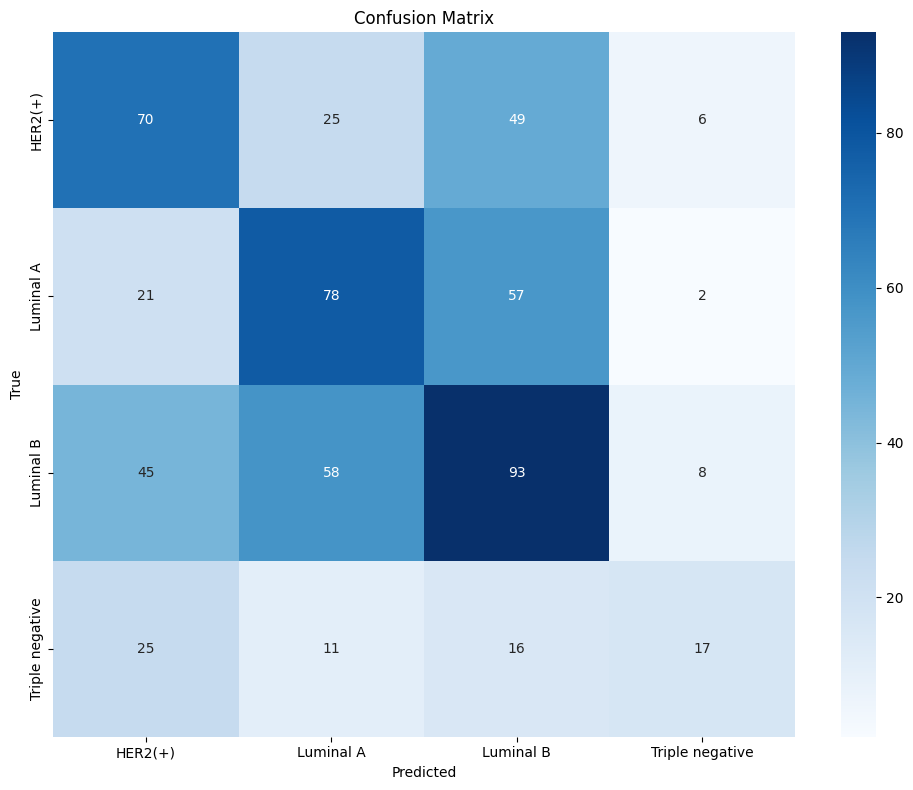


--- ERRORS: 323/581 (55.6%) ---

--- TOP 10 CONFIDENT MISCLASSIFICATIONS ---
  img_0471: True=HER2(+), Pred=Luminal B, Conf=93.1%
  img_0307: True=Triple negative, Pred=HER2(+), Conf=91.3%
  img_0331: True=HER2(+), Pred=Luminal A, Conf=87.1%
  img_0168: True=Luminal A, Pred=Luminal B, Conf=86.5%
  img_0003: True=Luminal B, Pred=Luminal A, Conf=83.5%
  img_0517: True=HER2(+), Pred=Luminal B, Conf=82.9%
  img_0455: True=Luminal B, Pred=Luminal A, Conf=82.7%
  img_0469: True=Luminal A, Pred=Luminal B, Conf=79.5%
  img_0197: True=Luminal A, Pred=Luminal B, Conf=79.1%
  img_0192: True=Luminal B, Pred=HER2(+), Conf=77.4%

✅ OOF F1 Score: 0.4441


In [21]:
def compute_mil_oof(train_bag_names, train_labels, mil_model_states, mil_params, feature_dim, features_dir, mask_features_dir=None, mask_feature_dim=768):
    """Compute OOF predictions with Two-Tower MIL (pre-extracted RGB + mask features)."""
    sgkf = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    oof_probs = np.zeros((len(train_bag_names), NUM_CLASSES))
    
    # Check if mask features directory exists
    use_masks = mask_features_dir is not None and Path(mask_features_dir).exists()
    
    for fold_idx, (_, val_idx) in enumerate(sgkf.split(train_bag_names, train_labels, np.arange(len(train_bag_names)))):
        model = create_mil_model(feature_dim, mil_params, use_mask_tower=use_masks, mask_feature_dim=mask_feature_dim)
        model.load_state_dict(strip_module_prefix(mil_model_states[fold_idx], model))
        model.eval()
        
        for vi in val_idx:
            bag_name = train_bag_names[vi]
            feats = torch.from_numpy(np.load(features_dir / f'{bag_name}_original.npy')).float().unsqueeze(0).to(DEVICE)
            attn_mask = torch.ones(1, feats.shape[1], dtype=torch.bool, device=DEVICE)
            
            # Load pre-extracted mask features
            mask_features = None
            if use_masks:
                mask_feat_file = Path(mask_features_dir) / f'{bag_name}_original.npy'
                if mask_feat_file.exists():
                    mask_features = torch.from_numpy(np.load(mask_feat_file)).float().unsqueeze(0).to(DEVICE)
                    # Ensure mask features match number of RGB patches
                    if mask_features.shape[1] != feats.shape[1]:
                        if mask_features.shape[1] < feats.shape[1]:
                            pad = torch.zeros(1, feats.shape[1] - mask_features.shape[1], mask_features.shape[2], device=DEVICE)
                            mask_features = torch.cat([mask_features, pad], dim=1)
                        else:
                            mask_features = mask_features[:, :feats.shape[1], :]
            
            with torch.no_grad():
                oof_probs[vi] = F.softmax(model(feats, attn_mask, mask_features=mask_features), 1).cpu().numpy()[0]
        del model
    return oof_probs

if mil_model_states:
    print("Computing OOF predictions...")
    train_bag_names = list(set(idx.replace('.png','').replace('.jpg','') for idx in train_orig_indices))
    train_labels_arr = np.array([image_label_lookup[f"{n}.png"] for n in train_bag_names])
    
    config_path = FEATURES_DIR / 'config.json'
    if config_path.exists():
        config = json.load(open(config_path))
        feature_dim = config['feature_dim']
    else:
        feature_dim = 1536
    
    # Load mask feature dim
    mask_config_path = FEATURES_DIR / 'mask_config.json'
    if mask_config_path.exists():
        mask_config = json.load(open(mask_config_path))
        mask_feature_dim = mask_config['feature_dim']
    else:
        mask_feature_dim = 768
    
    oof_probs = compute_mil_oof(
        train_bag_names, train_labels_arr, mil_model_states, mil_params, feature_dim, 
        FEATURES_DIR / 'features', 
        mask_features_dir=FEATURES_DIR / 'mask_features',
        mask_feature_dim=mask_feature_dim
    )
    oof_preds = oof_probs.argmax(1)
    
    cm, error_idx = analyze_errors(train_labels_arr, oof_preds, oof_probs, train_bag_names, CLASS_NAMES)
    
    oof_f1 = f1_score(train_labels_arr, oof_preds, average=F1_TYPE)
    print(f"\n✅ OOF F1 Score: {oof_f1:.4f}")
else:
    print("Train models first.")